In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install librosa tensorflow scikit-learn seaborn

In [3]:
import os

dataset_path = "/content/drive/MyDrive/NLP_PHASE_2/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path)[:5])

['OAF_happy', 'OAF_Fear', 'OAF_angry', 'OAF_disgust', 'OAF_neutral']


In [4]:
# SPEECH EMOTION RECOGNITION PROJECT


# IMPORT LIBRARIES


import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical


# DATASET PATH


DATASET_PATH = "/content/drive/MyDrive/NLP_PHASE_2/TESS Toronto emotional speech set data"

# LOAD AUDIO FILES + EXTRACT MFCC FEATURES


X = []
y = []

print("Loading dataset and extracting features...")

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            # extract emotion label
            emotion = file.split("_")[-1].replace(".wav", "")

            # FIX DUPLICATE LABEL ISSUE
            emotion = emotion.replace(" (1)", "")

            try:

                # load audio
                audio, sr = librosa.load(file_path, sr=22050)

                # extract MFCC features
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # mean pooling
                mfcc = np.mean(mfcc.T, axis=0)

                X.append(mfcc)
                y.append(emotion)

            except:
                print("Error processing:", file_path)

print("Feature extraction completed!")


# CONVERT TO NUMPY ARRAYS


X = np.array(X)
y = np.array(y)

print("\nFeature Shape:", X.shape)
print("Labels Shape:", y.shape)

# RESHAPE FOR CNN + LSTM


X = X.reshape(X.shape[0], X.shape[1], 1)

print("\nReshaped Feature Shape:", X.shape)


# ENCODE LABELS


encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

print("\nEmotion Classes:")
print(encoder.classes_)






Loading dataset and extracting features...
Feature extraction completed!

Feature Shape: (2803, 40)
Labels Shape: (2803,)

Reshaped Feature Shape: (2803, 40, 1)

Emotion Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [5]:
# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 2242
Testing Samples: 561


In [6]:

# BUILD CNN + LSTM MODEL


from tensorflow.keras.layers import Input

print("\nBuilding model...")

model = Sequential()


model.add(Input(shape=(40,1)))


model.add(
    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    )
)


model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    LSTM(64)
)


model.add(
    Dropout(0.3)
)


model.add(
    Dense(
        64,
        activation='relu'
    )
)


model.add(
    Dense(
        y_categorical.shape[1],
        activation='softmax'
    )
)


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()


Building model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,895 (148.03 KB)

 Trainable params: 37,895 (148.03 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# TRAIN MODEL


print("\nTraining model...")

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


# EVALUATE MODEL


print("\nEvaluating model...")

loss, accuracy = model.evaluate(X_test, y_test)

print("TEST ACCURACY:", accuracy)




Training model...
Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6472 - loss: 1.0927 - val_accuracy: 0.8788 - val_loss: 0.3911
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9112 - loss: 0.2781 - val_accuracy: 0.9216 - val_loss: 0.2359
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9416 - loss: 0.1809 - val_accuracy: 0.9465 - val_loss: 0.1687
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9567 - loss: 0.1421 - val_accuracy: 0.9501 - val_loss: 0.1267
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9719 - loss: 0.0878 - val_accuracy: 0.9643 - val_loss: 0.0966
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9853 - loss: 0.0652 - val_accuracy: 0.9750 - val_loss: 0.0742
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9764 - loss: 0.0705 - val_accuracy: 0.9661 - val_loss: 0.0901
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9786 - loss: 0.0668 - val_accurac

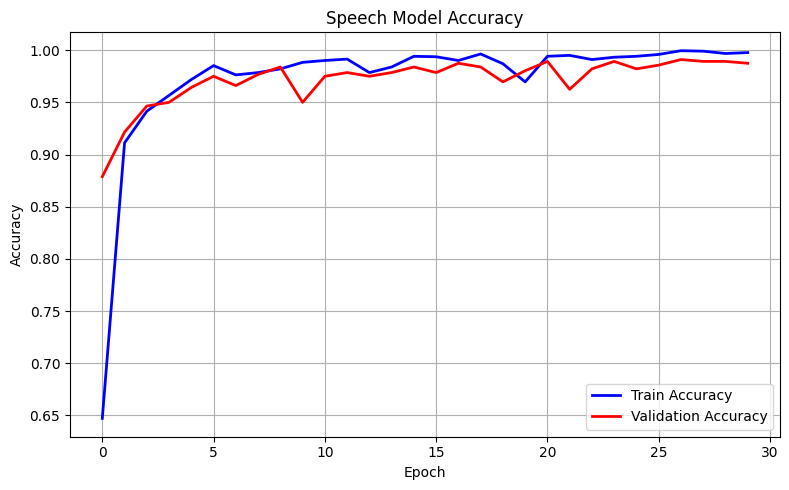

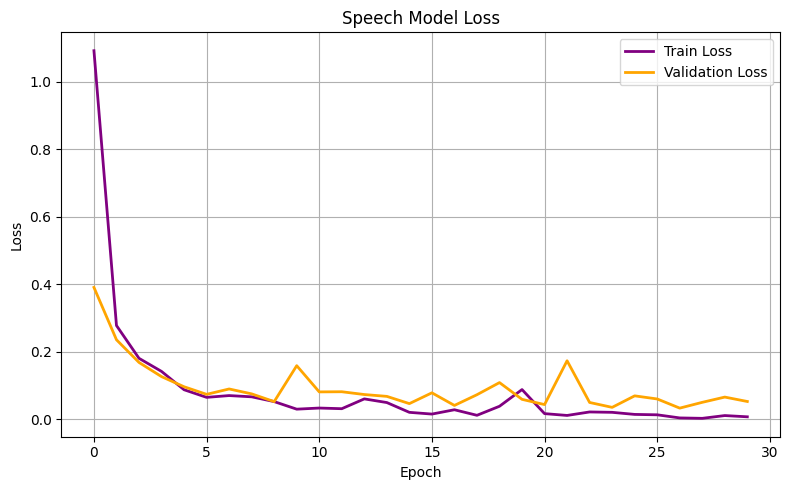


Generating confusion matrix...
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


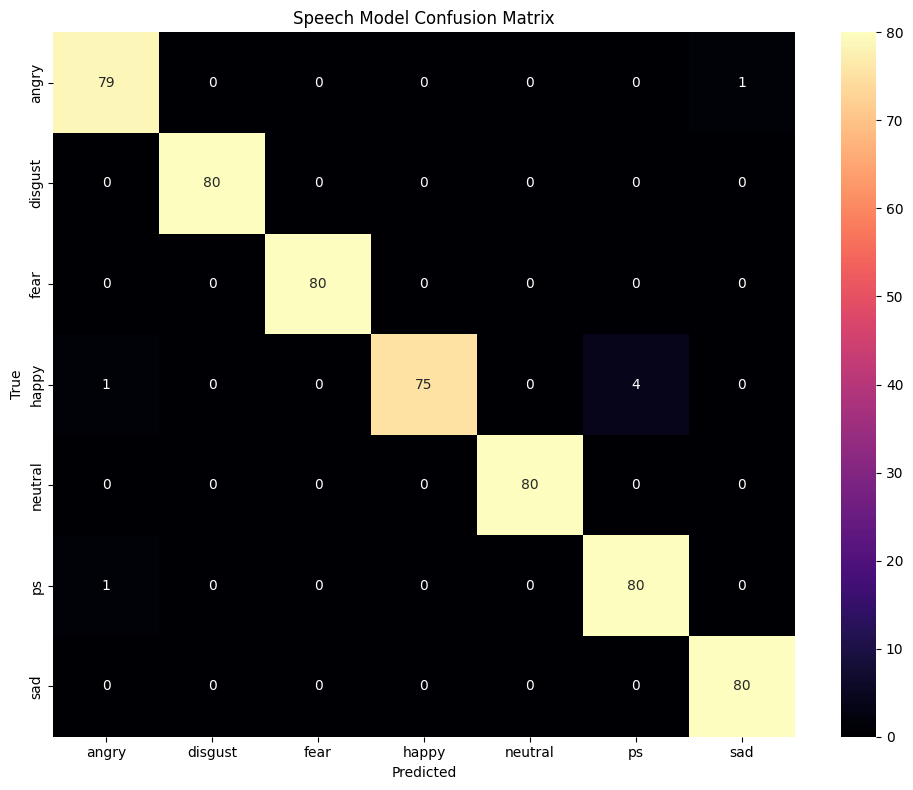


Classification Report:

              precision    recall  f1-score   support

       angry       0.98      0.99      0.98        80
     disgust       1.00      1.00      1.00        80
        fear       1.00      1.00      1.00        80
       happy       1.00      0.94      0.97        80
     neutral       1.00      1.00      1.00        80
          ps       0.95      0.99      0.97        81
         sad       0.99      1.00      0.99        80

    accuracy                           0.99       561
   macro avg       0.99      0.99      0.99       561
weighted avg       0.99      0.99      0.99       561



In [8]:

# ACCURACY PLOT


plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    color='blue',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    color='red',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Speech Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# LOSS PLOT


plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    color='purple',
    linewidth=2,
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    color='orange',
    linewidth=2,
    label='Validation Loss'
)

plt.title("Speech Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# CONFUSION MATRIX


print("\nGenerating confusion matrix...")

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Speech Model Confusion Matrix")

plt.tight_layout()

plt.show()


# CLASSIFICATION REPORT


print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred_classes,
        labels=np.arange(len(encoder.classes_)),
        target_names=encoder.classes_,
        zero_division=0
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


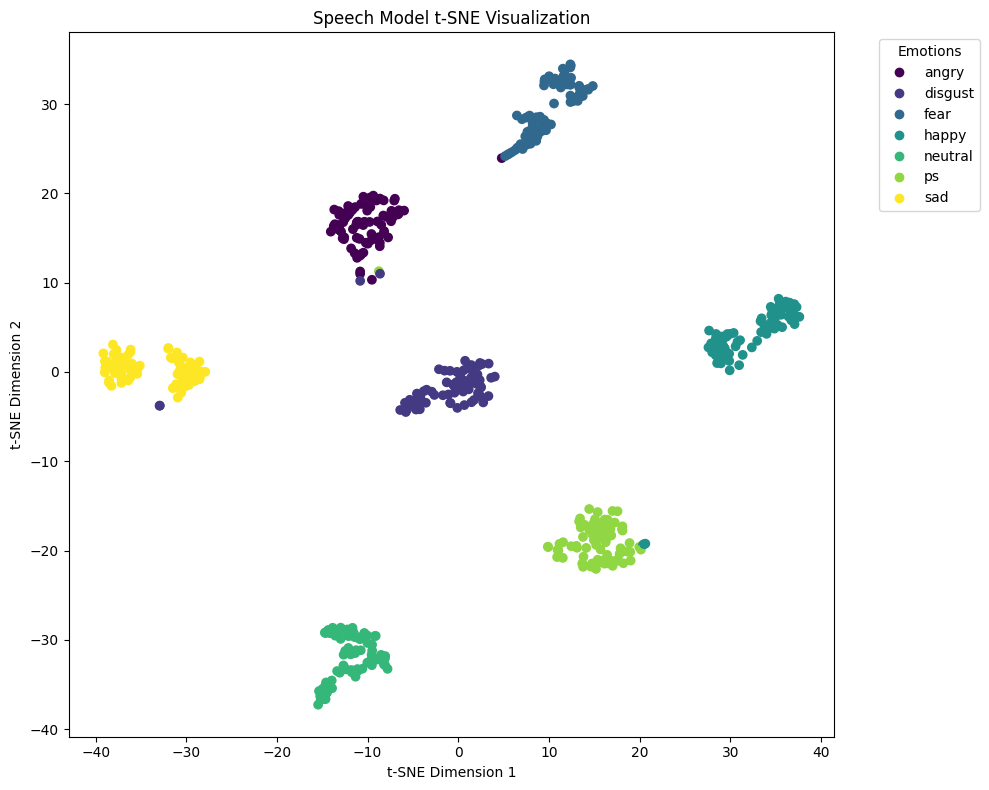

In [16]:

# SPEECH MODEL t-SNE VISUALIZATION


from sklearn.manifold import TSNE
from tensorflow.keras.models import Model


feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

speech_features = feature_extractor.predict(X_test)

tsne = TSNE(
    n_components=2,
    random_state=42
)

tsne_result = tsne.fit_transform(speech_features)


y_true = np.argmax(y_test, axis=1)

# PLOT


plt.figure(figsize=(10,8))

scatter = plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=y_true,
    cmap='viridis'
)


handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    encoder.classes_,
    title="Emotions",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("Speech Model t-SNE Visualization")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.tight_layout()

plt.show()

In [19]:
# SAVE MODEL


model.save("/content/drive/MyDrive/NLP_PHASE_2/speech_emotion_model.keras")

print("\nModel saved successfully!")

# PROJECT COMPLETED





Model saved successfully!
